In [23]:
import pandas as pd
import numpy as np
import plotly.express as px
from pathlib import Path

In [24]:
SCRIPTS = Path.cwd()
DATA = SCRIPTS.parent / "data"

In [25]:
acc_file = "/Users/rblc/create/work/elte/polar/scripts/app/recordings/momo_acc_260617_1300.csv"
ecg_file = "/Users/rblc/create/work/elte/polar/scripts/app/recordings/momo_ecg_260617_1300.csv" 

acc_df = pd.read_csv(DATA / acc_file)
ecg_df = pd.read_csv(DATA / ecg_file)

In [26]:
ecg_df.shape, acc_df.shape

((20586, 7), (32400, 9))

In [27]:
ecg_df.head(), acc_df.head()

(   packet_id  device_time_ms  host_time_ms   ecg  sample_idx  sample_time_ms  \
 0          0    5.996161e+11  1.781694e+12  4236           0    5.996161e+11   
 1          0    5.996161e+11  1.781694e+12  4085           1    5.996161e+11   
 2          0    5.996161e+11  1.781694e+12  4058           2    5.996161e+11   
 3          0    5.996161e+11  1.781694e+12  4058           3    5.996161e+11   
 4          0    5.996161e+11  1.781694e+12  3983           4    5.996161e+11   
 
    time_ms  
 0      0.0  
 1      5.0  
 2     10.0  
 3     15.0  
 4     20.0  ,
    packet_id  device_time_ms  host_time_ms    x    y    z  sample_idx  \
 0          0    5.996161e+11  1.781694e+12  144  630 -857           0   
 1          0    5.996161e+11  1.781694e+12  111  633 -868           1   
 2          0    5.996161e+11  1.781694e+12   89  636 -879           2   
 3          0    5.996161e+11  1.781694e+12   79  634 -871           3   
 4          0    5.996161e+11  1.781694e+12   66  632 -86

In [28]:
ecg_df = ecg_df.sort_values("time_ms")
acc_df = acc_df.sort_values("time_ms")

recording = pd.merge_asof(
    ecg_df,
    acc_df[["time_ms", "x", "y", "z"]],
    on="time_ms",
    direction="nearest"
)
recording = recording[["time_ms", "ecg", "x", "y", "z"]]
recording["acc_mag"] = np.sqrt(
    recording["x"]**2 +
    recording["y"]**2 +
    recording["z"]**2)

In [29]:
recording

,time_ms,ecg,x,y,z,acc_mag
0,0.000000,4236,144,630,-857,1073.352226
1,5.000000,4085,111,633,-868,1080.015741
2,10.000000,4058,111,633,-868,1080.015741
3,15.000000,4058,89,636,-879,1088.603693
4,20.000000,3983,79,634,-871,1080.202759
...,...,...,...,...,...,...
20581,158164.050659,-47,-43,-793,-572,978.714463
20582,158169.050659,-52,-26,-823,-571,1002.020958
20583,158174.050659,-59,-58,-791,-578,981.391359
20584,158179.050659,-61,-65,-787,-584,982.165974


In [30]:


import neurokit2 as nk

fs = 130

_, info = nk.ecg_peaks(
    recording["ecg"],
    sampling_rate=fs
)

rpeaks = info["ECG_R_Peaks"]

recording["r_peak"] = 0
recording.loc[rpeaks, "r_peak"] = 1

In [31]:
recording

,time_ms,ecg,x,y,z,acc_mag,r_peak
0,0.000000,4236,144,630,-857,1073.352226,0
1,5.000000,4085,111,633,-868,1080.015741,0
2,10.000000,4058,111,633,-868,1080.015741,0
3,15.000000,4058,89,636,-879,1088.603693,0
4,20.000000,3983,79,634,-871,1080.202759,0
...,...,...,...,...,...,...,...
20581,158164.050659,-47,-43,-793,-572,978.714463,0
20582,158169.050659,-52,-26,-823,-571,1002.020958,0
20583,158174.050659,-59,-58,-791,-578,981.391359,0
20584,158179.050659,-61,-65,-787,-584,982.165974,0


In [41]:
segment = recording.query(
    "60000 <= time_ms <= 80000"
)

peaks = segment[segment["r_peak"] == 1]

fig = px.line(
    segment,
    x="time_ms",
    y="ecg"
)

fig.add_scatter(
    x=peaks["time_ms"],
    y=peaks["ecg"],
    mode="markers",
    name="R peaks"
)

fig.show()

In [33]:
import numpy as np
import pandas as pd

# R-peak times
rpeak_times = recording.loc[recording["r_peak"] == 1, "time_ms"].to_numpy()

# -----------------------------
# 1) Beat-to-beat HR / HRV
# -----------------------------
rr_ms = np.diff(rpeak_times)

hrv_df = pd.DataFrame({
    "time_ms": rpeak_times[1:],
    "rr_ms": rr_ms,
    "bpm_instant": 60000 / rr_ms
})

# -----------------------------
# 2) 1-second sport-watch-like BPM
# -----------------------------
bpm_df = (
    hrv_df
    .set_index(pd.to_timedelta(hrv_df["time_ms"], unit="ms"))
    .resample("1s")
    .mean(numeric_only=True)
    .interpolate()
    .reset_index(drop=True)
)

bpm_df["time_ms"] = np.arange(len(bpm_df)) * 1000
bpm_df["bpm"] = bpm_df["bpm_instant"].rolling(
    window=5,
    center=True,
    min_periods=1
).mean()

bpm_df = bpm_df[["time_ms", "bpm"]]

In [34]:
px.line(
    hrv_df,
    x="time_ms",
    y="rr_ms",
    title="RR Intervals Over Time"
)

In [35]:
px.line(
    bpm_df,
    x="time_ms",
    y="bpm",
    title="BPM Over Time"
)

In [36]:
px.line(
    hrv_df,
    x="time_ms",
    y="rr_ms",
    title="RR Intervals Over Time"
)

In [37]:
rr = hrv_df["rr_ms"]

px.scatter(
    x=rr[:-1],
    y=rr[1:],
    title="Poincaré of RR Intervals",
    labels={"x": "RR(n) [ms]", "y": "RR(n+1) [ms]"}
)

In [38]:
rr_diff = np.diff(hrv_df["rr_ms"])

hrv_df["rmssd_30"] = (
    pd.Series(rr_diff**2)
    .rolling(30)
    .mean()
    .pow(0.5)
)

px.line(
    hrv_df.iloc[1:],
    x="time_ms",
    y="rmssd_30",
    title="HRV Over Time"
)

<Axes: >

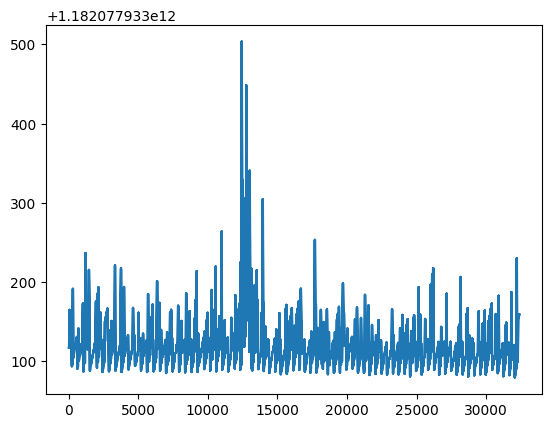

In [39]:
acc_df["delta_time"] = acc_df["host_time_ms"] - acc_df["device_time_ms"]
acc_df["delta_time"].plot()